In [1]:
!pip install -q --no-cache-dir --force-reinstall --no-deps git+https://github.com/RayenSansa03/aeroguard.git@main

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [1]:
from google.colab import drive
drive.mount("/content/drive")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from aeroguard.donnees_ml import preparer_xy
from aeroguard.rarete import bilan_classes, ratio_desequilibre, zone_critique

DOSSIER = "/content/drive/MyDrive/aeroguard"
SEUIL_CRITIQUE = 10  # zone critique = 10 derniers vols avant la panne

vols = pd.read_parquet(f"{DOSSIER}/data/processed/vols_ncmapss.parquet")

# Règle d'or du module 6 : on analyse (et plus tard on générera) uniquement à partir du TRAIN
X_train, y_train = preparer_xy(vols, "train")
X_val, y_val = preparer_xy(vols, "val")

infos_train = vols.loc[X_train.index, ["moteur", "cycle", "RUL", "famille"]].copy()
infos_train["famille"] = infos_train["famille"].astype(str)
infos_train["use"] = np.asarray(y_train)
infos_val = vols.loc[X_val.index, ["moteur", "famille"]].astype({"famille": str})

print(f"Train : {len(infos_train)} vols, {infos_train['moteur'].nunique()} moteurs")
print(f"Val   : {len(infos_val)} vols, {infos_val['moteur'].nunique()} moteurs")

Mounted at /content/drive
Train : 3716 vols, 49 moteurs
Val   : 819 vols, 11 moteurs


In [2]:
etat_vol = infos_train["use"].map({0: "sain", 1: "usé"})
bilan_vols = bilan_classes(etat_vol)

print(bilan_vols.round(3))
print(f"\nRatio de déséquilibre sain/usé : {ratio_desequilibre(etat_vol):.2f}")

        effectif  proportion
classe                      
sain        1096       0.295
usé         2620       0.705

Ratio de déséquilibre sain/usé : 2.39


In [3]:
moteurs_train = infos_train.drop_duplicates("moteur")
bilan_familles = bilan_classes(moteurs_train["famille"])
print("Moteurs par famille (TRAIN) :")
print(bilan_familles.round(3))
print(f"\nRatio de déséquilibre entre familles (train) : {ratio_desequilibre(moteurs_train['famille']):.1f}")

# Pour comparaison : train + validation (le protocole « panne inconnue » de la 5.4)
moteurs_train_val = pd.concat([moteurs_train[["moteur", "famille"]],
                               infos_val.drop_duplicates("moteur")[["moteur", "famille"]]])
print("\nMoteurs par famille (TRAIN + VAL) :")
print(bilan_classes(moteurs_train_val["famille"])["effectif"])

Moteurs par famille (TRAIN) :
         effectif  proportion
classe                       
HPC             5       0.102
LPC+HPC         5       0.102
fan             5       0.102
HPT+LPT         6       0.122
HPT             8       0.163
LPT             8       0.163
mixte          12       0.245

Ratio de déséquilibre entre familles (train) : 2.4

Moteurs par famille (TRAIN + VAL) :
classe
HPC         6
LPC+HPC     6
fan         6
HPT         9
HPT+LPT     9
LPT         9
mixte      15
Name: effectif, dtype: int64


In [8]:
critique = zone_critique(infos_train["RUL"], seuil=SEUIL_CRITIQUE)
infos_train["critique"] = critique

nb_vols = len(infos_train)
nb_uses = int(infos_train["use"].sum())
nb_critiques = int(critique.sum())

print(f"Vols critiques : {nb_critiques} sur {nb_vols} vols du train ({nb_critiques / nb_vols:.1%})")
print(f"Vols critiques parmi les vols usés : {nb_critiques} sur {nb_uses} ({nb_critiques / nb_uses:.1%})")

# Trois niveaux de rareté : sain, usé mais pas encore critique, critique
niveau = np.where(critique, "critique (RUL ≤ 10)", np.where(infos_train["use"] == 1, "usé", "sain"))
bilan_niveaux = bilan_classes(niveau)
print()
print(bilan_niveaux.round(3))
ratio_sain_critique = (niveau == "sain").sum() / (niveau == "critique (RUL ≤ 10)").sum()
print(f"\nRatio sain/critique : {ratio_sain_critique:.1f}")
print(f"Ratio plus fréquent / plus rare (usé/critique) : {ratio_desequilibre(niveau):.1f}")

Vols critiques : 539 sur 3716 vols du train (14.5%)
Vols critiques parmi les vols usés : 539 sur 2620 (20.6%)

                     effectif  proportion
classe                                   
critique (RUL ≤ 10)       539       0.145
sain                     1096       0.295
usé                      2081       0.560

Ratio sain/critique : 2.0
Ratio plus fréquent / plus rare (usé/critique) : 3.9


In [9]:
rarete_familles = (
    infos_train.groupby("famille")
    .agg(moteurs=("moteur", "nunique"),
         vols=("moteur", "size"),
         vols_uses=("use", "sum"),
         vols_critiques=("critique", "sum"))
    .sort_values("vols_critiques")
)
rarete_familles["part_critique"] = rarete_familles["vols_critiques"] / nb_vols
rarete_familles["critiques_par_moteur"] = rarete_familles["vols_critiques"] / rarete_familles["moteurs"]

rarete_familles.to_csv(f"{DOSSIER}/results/61_rarete_familles.csv")
rarete_familles.round(3)

,moteurs,vols,vols_uses,vols_critiques,part_critique,critiques_par_moteur
famille,,,,,,
HPC,5,411,281,55,0.015,11.0
LPC+HPC,5,376,267,55,0.015,11.0
fan,5,429,340,55,0.015,11.0
HPT+LPT,6,437,306,66,0.018,11.0
HPT,8,699,529,88,0.024,11.0
LPT,8,615,382,88,0.024,11.0
mixte,12,749,515,132,0.036,11.0


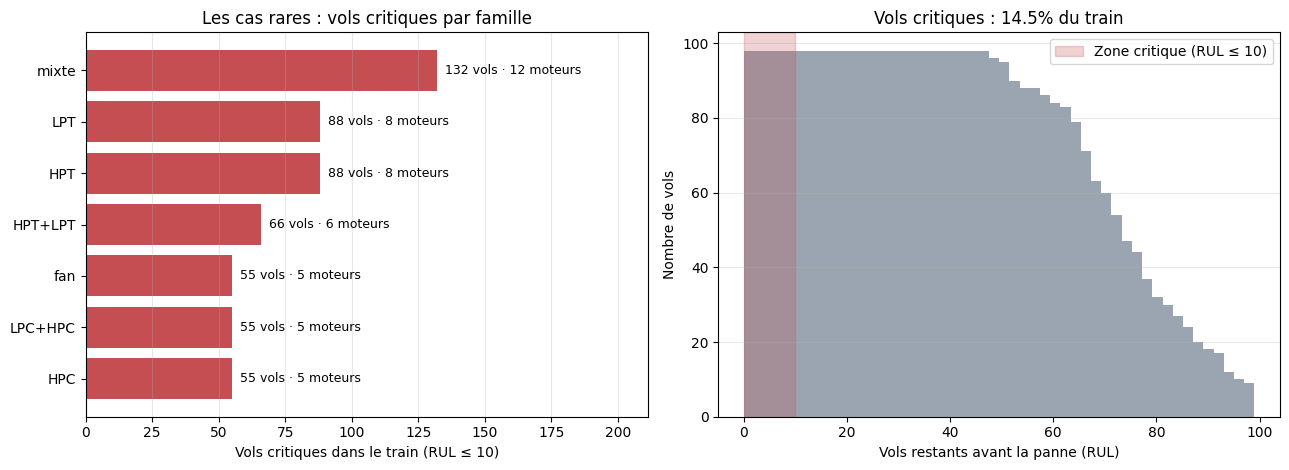

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8))

# Gauche : vols critiques par famille (de la plus rare à la plus fréquente)
ax1.barh(rarete_familles.index, rarete_familles["vols_critiques"], color="#C44E52")
for position, (vols_crit, moteurs) in enumerate(zip(rarete_familles["vols_critiques"],
                                                    rarete_familles["moteurs"])):
    ax1.text(vols_crit, position, f"  {vols_crit} vols · {moteurs} moteurs", va="center", fontsize=9)
ax1.set_xlabel("Vols critiques dans le train (RUL ≤ 10)")
ax1.set_title("Les cas rares : vols critiques par famille")
ax1.set_xlim(0, rarete_familles["vols_critiques"].max() * 1.6)
ax1.grid(alpha=0.3, axis="x")

# Droite : distribution de la RUL, avec la zone critique
ax2.hist(infos_train["RUL"], bins=50, color="#9AA5B1")
ax2.axvspan(0, SEUIL_CRITIQUE, color="#C44E52", alpha=0.25,
            label=f"Zone critique (RUL ≤ {SEUIL_CRITIQUE})")
ax2.set_xlabel("Vols restants avant la panne (RUL)")
ax2.set_ylabel("Nombre de vols")
ax2.set_title(f"Vols critiques : {nb_critiques / nb_vols:.1%} du train")
ax2.legend()
ax2.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(f"{DOSSIER}/results/figures/61_rarete.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
moteurs_min = rarete_familles["moteurs"].min()
familles_rares = rarete_familles.index[rarete_familles["moteurs"] == moteurs_min].tolist()

resume = {
    "vols_train": nb_vols,
    "moteurs_train": int(infos_train["moteur"].nunique()),
    "part_uses": round(nb_uses / nb_vols, 3),
    "ratio_sain_use": round(ratio_desequilibre(etat_vol), 2),
    "part_critiques": round(nb_critiques / nb_vols, 3),
    "ratio_sain_critique": round(float(ratio_sain_critique), 1),
    "ratio_use_critique": round(ratio_desequilibre(niveau), 1),
    "ratio_familles_moteurs": round(ratio_desequilibre(moteurs_train["famille"]), 1),
    "familles_les_plus_rares": ", ".join(familles_rares),
    "moteurs_par_famille_rare": int(moteurs_min),
    "vols_critiques_par_famille_rare": int(rarete_familles.loc[familles_rares[0], "vols_critiques"]),
}
for cle, valeur in resume.items():
    print(f"{cle:32s} {valeur}")

vols_train                       3716
moteurs_train                    49
part_uses                        0.705
ratio_sain_use                   2.39
part_critiques                   0.145
ratio_sain_critique              2.0
ratio_use_critique               3.9
ratio_familles_moteurs           2.4
familles_les_plus_rares          HPC, LPC+HPC, fan
moteurs_par_famille_rare         5
vols_critiques_par_famille_rare  55
